In [1]:
%load_ext autoreload
%autoreload 2

# RNN Model Training 2

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import joblib
import matplotlib.dates as mdates
from sklearn.metrics import  r2_score
# set up relative imports
project_folder = Path.cwd().parent.parent
sys.path.append(str(project_folder))

In [31]:
from modeling.model.lstm import create_lstm_model, get_callbacks
from modeling.utilities.data_prep import setup_sequential_data, create_split_dfs

#### read in data

In [32]:
data_folder = Path(r'..\data\model-ready\water-weather-wind')

# train
train_X_df = pd.read_parquet(data_folder / 'scaled-X-train.parquet')
train_y_df = pd.read_parquet(data_folder / 'Y-train.parquet') 

# test
test_X_df = pd.read_parquet(data_folder / 'scaled-X-test.parquet')
test_y_df = pd.read_parquet(data_folder / 'Y-test.parquet') 

# val
val_X_df = pd.read_parquet(data_folder / 'scaled-X-val.parquet')
val_y_df = pd.read_parquet(data_folder / 'Y-val.parquet') 



In [33]:
scaler = joblib.load(data_folder / 'minmax_scaler.joblib')

In [34]:
train_X_df

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,sin_day,cos_day,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave
0,0.294007,0.335280,0.108696,0.225,0.000000,0.263514,0.192857,0.0,0.033333,0.0,...,0.697431,0.959375,0.943951,0.271766,0.878641,0.460495,0.158109,0.042587,0.830645,0.473512
1,0.305315,0.339496,0.130435,0.350,0.395604,0.256757,0.185714,0.0,0.066667,0.0,...,0.786001,0.910151,0.938372,0.261235,0.883153,0.449983,0.152676,0.045999,0.887392,0.483829
2,0.338583,0.444552,0.000000,0.225,0.219780,0.236486,0.164286,0.0,0.100000,0.0,...,0.862862,0.844083,0.730039,0.056431,0.803887,0.309658,0.143847,0.075283,0.954677,0.432359
3,0.260083,0.282612,0.152174,0.225,0.000000,0.256757,0.185714,0.0,0.133333,0.0,...,0.924867,0.763876,0.991769,0.412327,0.875522,0.541327,0.143439,0.065284,0.952957,0.477256
4,0.153723,0.195623,0.108696,0.175,0.000000,0.256757,0.185714,0.0,0.166667,0.0,...,0.969479,0.672813,0.976554,0.655684,0.800069,0.628293,0.143168,0.058444,0.907132,0.576297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3914,0.477196,0.454428,0.478261,0.600,0.186813,0.381757,0.328571,1.0,0.766667,1.0,...,0.005131,0.574623,0.705034,0.044263,0.831122,0.189058,0.315403,0.051281,0.807787,0.338311
3915,0.430833,0.481577,0.304348,0.450,0.000000,0.385135,0.335714,1.0,0.800000,1.0,...,0.030521,0.672813,0.633275,0.018208,0.774677,0.206588,0.314588,0.050788,0.854946,0.243670
3916,0.350923,0.391209,0.282609,0.325,0.091575,0.389640,0.357143,1.0,0.833333,1.0,...,0.075133,0.763876,0.850981,0.144844,0.867537,0.356191,0.319478,0.044439,0.903744,0.172245
3917,0.236336,0.451067,0.195652,0.300,0.014652,0.394144,0.346429,1.0,0.866667,1.0,...,0.137138,0.844083,0.713620,0.048247,0.765960,0.387336,0.319886,0.044918,0.867804,0.282377


#### set up sequential data

In [99]:
val_X_df.reset_index(drop=True, inplace=True)
val_y_df.reset_index(drop=True, inplace=True)

val_df = val_X_df.join(val_y_df)
val_df.head(3)

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,cos_day,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave,target
0,0.060309,0.256496,0.347826,0.325,0.000000,0.270270,0.228571,0.090909,0.266667,0.0,...,0.373065,0.999705,0.485766,0.740892,0.582502,0.195599,0.069833,0.743313,0.577522,15.6
1,0.067848,0.239948,0.260870,0.475,0.073260,0.270270,0.235714,0.090909,0.300000,0.0,...,0.277951,0.999163,0.532598,0.746027,0.588542,0.199674,0.050088,0.743472,0.651148,15.6
2,0.152829,0.276886,0.282609,0.425,0.435897,0.277027,0.235714,0.090909,0.333333,0.0,...,0.191874,0.994425,0.428314,0.803431,0.563235,0.197229,0.039646,0.802819,0.717936,15.7


In [ ]:
train_X_df.reset_index(drop=True, inplace=True)
train_y_df.reset_index(drop=True, inplace=True)

train_df = train_X_df.join(train_y_df)
train_df.head(3)

In [40]:
train_df[train_df.target.isnull()]

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,cos_day,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave,target


In [41]:
def recreate_date_column(df, scaler)->pd.Series:
    df = df.copy()
    unscaled_data = scaler.inverse_transform(df)
    df = pd.DataFrame(columns=df.columns, data=unscaled_data)
    df['date'] = pd.to_datetime(df[['year','month','day']], 
                                errors='coerce'
                                )
    return df['date']


In [42]:
df_date = recreate_date_column(train_X_df, scaler)

In [43]:
train_df['date'] = df_date

In [44]:
train_df.head(2)

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave,target,date
0,0.294007,0.335280,0.108696,0.225,0.000000,0.263514,0.192857,0.0,0.033333,0.0,...,0.943951,0.271766,0.878641,0.460495,0.158109,0.042587,0.830645,0.473512,15.3,2005-01-02
1,0.305315,0.339496,0.130435,0.350,0.395604,0.256757,0.185714,0.0,0.066667,0.0,...,0.938372,0.261235,0.883153,0.449983,0.152676,0.045999,0.887392,0.483829,15.1,2005-01-03


In [45]:
train_df[train_df.target.isnull()]

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave,target,date


In [46]:
train_dfs = create_split_dfs(train_df)

In [47]:
df = train_dfs[1]
df[df.target.isnull()]

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave,target,date


In [ ]:
def setup_seq_data_df_list(data_dfs: list[pd.DataFrame], 
                           seq_size: int, 
                           remove_cols: list, 
                           target_col: str
                           ):
    X_trains = []
    y_trains = []
    if target_col not in remove_cols:
        remove_cols.append(target_col)
    for df in data_dfs:
        train_cols = list(df.columns)
        for col in remove_cols:
            train_cols.remove(col)
        x_train_df = df[train_cols]
        y_train_df = df[[target_col]]
        X_train, y_train = setup_sequential_data(x_train_df, y_train_df, seq_size)
        #for x, y in zip(X_train, y_train):
        if len(X_train.shape) == 3:
            X_trains.append(X_train)
            y_trains.append(y_train)

    full_data_x = np.concatenate(X_trains)
    full_data_y = np.concatenate(y_trains)

    return full_data_x, full_data_y

In [70]:
X_trains = []
y_trains = []
seq_size = 10
for df in train_dfs:
    train_cols = list(df.columns)
    train_cols.remove('target')
    train_cols.remove('date')
    x_train_df = df[train_cols]
    y_train_df = df[['target']]
    X_train, y_train = setup_sequential_data(x_train_df, y_train_df, seq_size)
    #for x, y in zip(X_train, y_train):
    if len(X_train.shape) == 3:
        X_trains.append(X_train)
        y_trains.append(y_train)

In [71]:
X_trains[0].shape

(29, 10, 24)

In [72]:
X_trains[1].shape

(29, 10, 24)

In [73]:
len(X_trains)

112

array([15.6, 15.3, 15.4, ..., 17.9, 17.7, 17.5], shape=(2856,))

In [83]:
y_trains[4].shape

(10,)

In [86]:
X_seq_train = np.concatenate(X_trains, axis=0)

In [87]:
X_seq_train.shape

(2856, 10, 24)

In [89]:
X_seq_train = np.concatenate(X_trains)
y_seq_train = np.concatenate(y_trains)

In [ ]:
X_seq_train, y_seq_train = setup_seq_data_df_list(train_dfs, 10, ['date'], 'target')
X_seq_val, y_seq_val = setup_seq_data_df_list(val_dfs, 10, ['date'], 'target')

In [97]:
y_seq_train.shape

(2856,)

In [98]:
X_seq_train.shape

(2856, 10, 24)

### Compile and Train the model

In [91]:
input_shape = (X_seq_train.shape[1], X_seq_train.shape[2])

In [92]:
model = create_lstm_model(input_shape)

In [93]:
model.compile(optimizer='adam', loss='mse',)

In [14]:
history = model.fit(X_train, 
          y_train, 
          epochs=100, 
          batch_size=32,
          validation_data=(X_val, y_val),
          callbacks=get_callbacks()
          )

Epoch 1/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - loss: 23.7334 - val_loss: 7.3800 - learning_rate: 0.0010
Epoch 2/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 7.4609 - val_loss: 3.4837 - learning_rate: 0.0010
Epoch 3/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 2.7263 - val_loss: 1.6092 - learning_rate: 0.0010
Epoch 4/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 2.0832 - val_loss: 0.8493 - learning_rate: 0.0010
Epoch 5/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 1.8711 - val_loss: 0.6769 - learning_rate: 0.0010
Epoch 6/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 1.8099 - val_loss: 0.5533 - learning_rate: 0.0010
Epoch 7/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 1.7560 - val_loss: 0.5444 - learning_rate: 0.0010
Epoch 8/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 1.7098 - val_loss: 0.4436 - learning_rate: 0.0010
Epoch 9/100
682/682 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 1.6880 - val_loss: 0.5040 - learning_ra

#### Evaluate the model

In [15]:
y_pred = model.predict(X_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [16]:
test_x_unscaled = scaler.inverse_transform(test_X_df)
test_x_df = pd.DataFrame(columns=test_X_df.columns, data=test_x_unscaled)

In [17]:
test_x_df.shape

(5170, 16)

In [18]:
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred.flatten()
}, index=test_x_df.index[seq_size - 1:])

In [19]:
results_df

,actual,predicted
9,19.00,20.418621
10,19.30,18.776321
11,18.70,18.423546
12,18.90,18.684473
13,19.00,18.655613
...,...,...
5165,17.50,17.620234
5166,17.25,17.209822
5167,17.10,16.880751
5168,17.20,17.185431


In [20]:
len(y_pred)

5161

In [21]:
test_x_df = test_x_df.join(results_df,
                how='inner')

In [22]:
test_x_df['date'] = pd.to_datetime(test_x_df[['year','month','day']], errors='coerce')

In [23]:
test_x_df['errors'] = test_x_df.predicted - test_x_df.actual

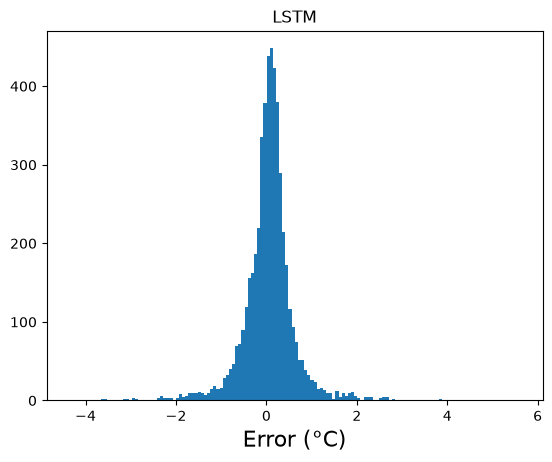

In [24]:
plt.hist(test_x_df.errors, bins='auto')
plt.title('LSTM')
plt.xlabel('Error (\u00b0C)', fontsize=16)
plt.show()

In [25]:
pd.DataFrame(test_x_df.errors.describe()).T

,count,mean,std,min,25%,50%,75%,max
errors,5161.0,0.054484,0.60033,-4.359789,-0.168768,0.077033,0.290063,5.613003


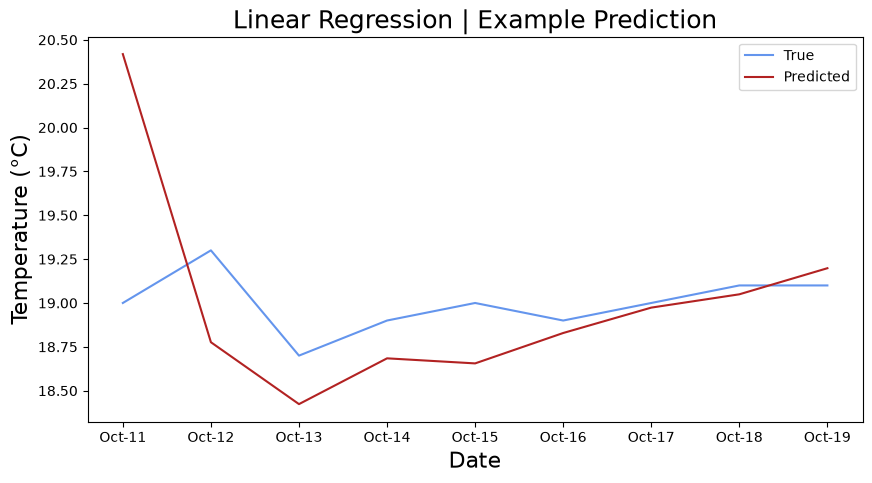

In [28]:
plot_df = test_x_df[:9].copy()
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(plot_df.date, plot_df.actual, label='True', color='cornflowerblue')
ax.plot(plot_df.date, plot_df.predicted, label='Predicted', color='firebrick')
ax.set_ylabel('Temperature (\u00b0C)', fontsize=16)
ax.set_xlabel('Date', fontsize=16)
ax.set_title('Linear Regression | Example Prediction', fontsize=18)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.show()

In [29]:
mse = np.mean([x**2 for x in test_x_df.errors])
rmse = np.sqrt(mse)
r_2 = r2_score(y_test, y_pred)

print(f'RMSE = {round(rmse, 2)}')
print(f'r2 score = {round(r_2, 2)}')

RMSE = 0.6
r2 score = 0.95
